### Упражнение 1

- Рассмотрим в качестве сезонной составляющей периодический сигнал с периодом 12
```python
time = np.arange(144)
seasonal_12 = 20 + np.sin(2*np.pi*time/12)*20
```
- Используйте `seasonal_12` и компоненты `trend` и `residual` ниже, чтобы определить и построить аддитивную и мультипликативную модели
```python
trend = time * 2.65 + 100
residuals = np.random.normal(loc=0.0, scale=3, size=len(time))
```
- Выполните сезонную декомпозицию с `seasonal_decompose` и `STL` для новых сигналов и сравните результаты с полученными в классе, где мы использовали приблизительный период.

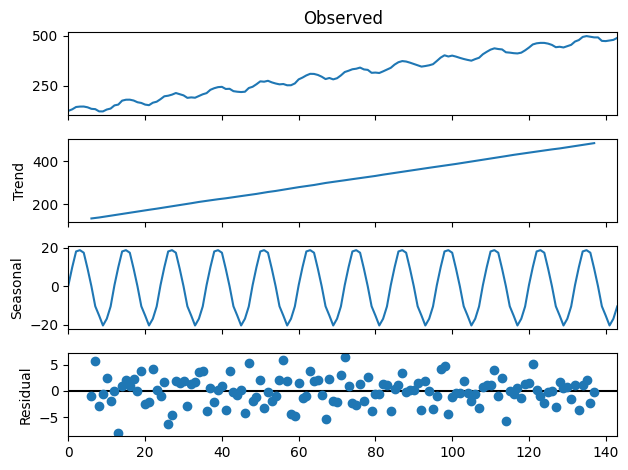

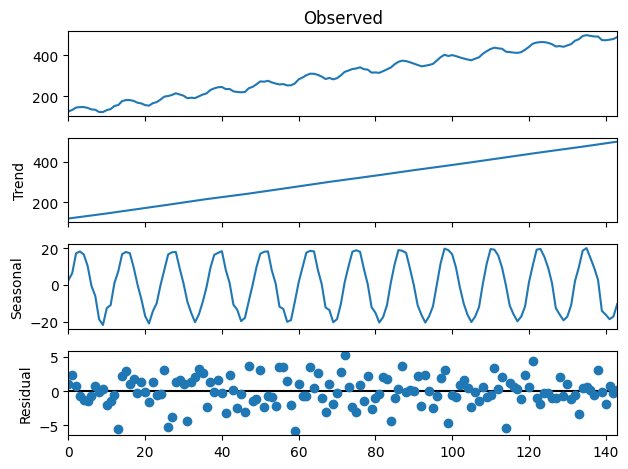

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL

time = np.arange(144)
seasonal_12 = 20 + np.sin(2 * np.pi * time / 12) * 20
trend = time * 2.65 + 100
residuals = np.random.normal(loc=0.0, scale=3, size=len(time))

# модели
add_data = trend + seasonal_12 + residuals
mult_data = trend * (seasonal_12 / np.mean(seasonal_12)) + residuals

# декомпозиция для аддитивной
res_add = seasonal_decompose(add_data, model='additive', period=12)
res_stl = STL(add_data, period=12).fit()

# отрисовка
res_add.plot()
plt.show()

res_stl.plot()
plt.show()


### Упражнение 2
Загрузите два разных временных ряда следующим образом.
```python
import statsmodels.api as sm
ts_A = sm.datasets.get_rdataset("AirPassengers", "datasets").data["value"].values
print(len(ts_A))
ts_B = sm.datasets.get_rdataset("co2", "datasets").data["value"].values
print(len(ts_B))
```
- Постройте график двух временных рядов.
- Определите, выглядит ли временной ряд аддитивной или мультипликативной моделью.
- Определите основной период сезонной составляющей в двух временных рядах.

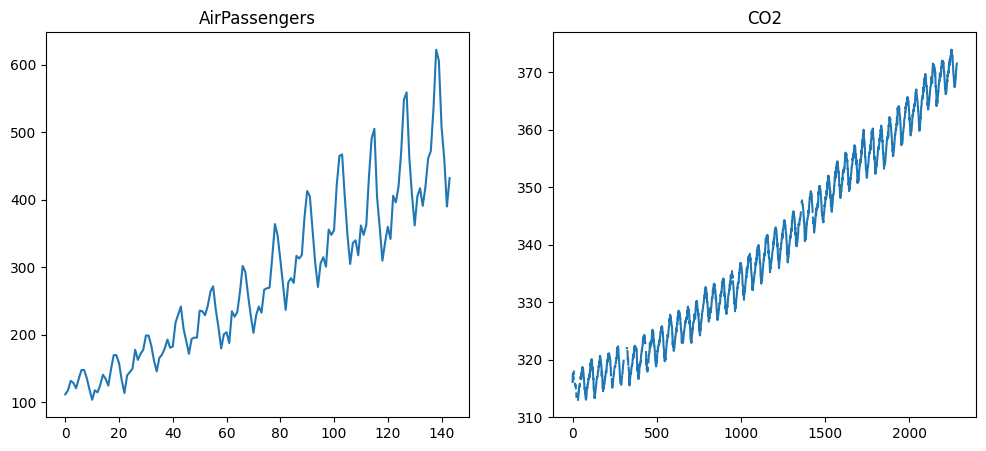

In [3]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

ts_A = sm.datasets.get_rdataset("AirPassengers", "datasets").data["value"].values

data_co2 = sm.datasets.co2.load_pandas()
ts_B = data_co2.data['co2'].values

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(ts_A)
plt.title("AirPassengers")

plt.subplot(1, 2, 2)
plt.plot(ts_B)
plt.title("CO2")
plt.show()

для ряда ts_A (AirPassengers) лучше подходит мультипликативная модель. на графике заметно, что размах сезонных колебаний увеличивается по мере роста самого тренда.

для ряда ts_B (co2) подходит аддитивная модель. в отличие от первого графика, здесь амплитуда сезонных волн остается практически постоянной, хотя общий уровень концентрации углекислого газа постоянно растет.

основной период сезонности для обоих рядов равен 12. это связано с тем, что данные в этих датасетах собирались помесячно, и цикл полностью повторяется раз в год.


### Упражнение 3
- Разложите `ts_A` и `ts_B` с помощью `seasonal_decompose` и `STL`.
- Прокомментируйте полученные результаты.
from statsmodels.tsa.seasonal import season_decompose, STL

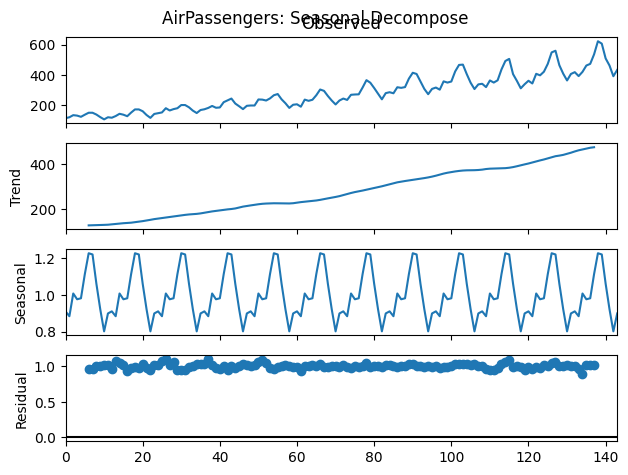

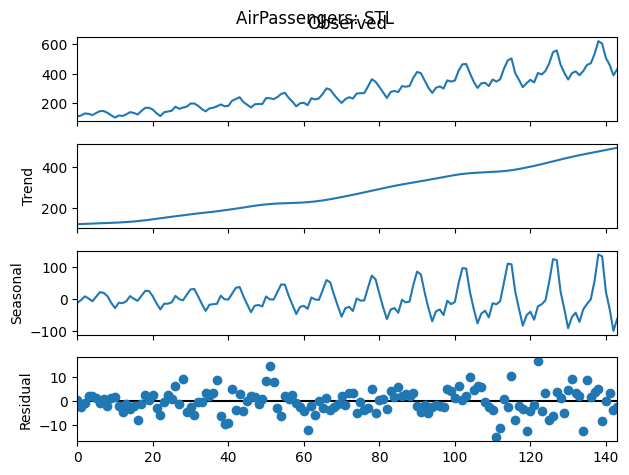

In [4]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL
import pandas as pd

# загрузка и очистка
ts_A = sm.datasets.get_rdataset("AirPassengers", "datasets").data["value"].values

data_co2 = sm.datasets.co2.load_pandas().data
ts_B_series = data_co2['co2'].interpolate() # заполняем пропуски
ts_B = ts_B_series.values

# декомпозиция ts_A (мультипликативная)
res_a_sd = seasonal_decompose(ts_A, model='multiplicative', period=12)
res_a_stl = STL(ts_A, period=12).fit()

# декомпозиция ts_B (аддитивная)
res_b_sd = seasonal_decompose(ts_B, model='additive', period=12)
res_b_stl = STL(ts_B, period=12).fit()

# вывод графиков для ts_A
res_a_sd.plot()
plt.suptitle('AirPassengers: Seasonal Decompose')
plt.show()

res_a_stl.plot()
plt.suptitle('AirPassengers: STL')
plt.show()

результаты декомпозиции airpassengers подтверждают, что этот ряд мультипликативный. на верхнем графике seasonal_decompose видно, что сезонная составляющая меняется от 0.8 до 1.2 — это коэффициенты, на которые умножается тренд. остатки  при этом получились плотными и без явных структур, значит модель подобрана верно.

на нижнем графике stl сезонность выражена в абсолютных единицах (от -100 до 100), так как этот метод по умолчанию аддитивный. из-за этого в остатках stl виден шум, который увеличивается к концу временного ряда вслед за ростом пассажиропотока.

оба метода четко выделили возрастающий линейный тренд и годовую цикличность с периодом 12. stl лучше отрисовал края ряда, в то время как обычная декомпозиция оставила пустые места в начале и конце из-за использования скользящего среднего.